<img src="content.png" width="100">

# Juan David Valencia

Fundamentos de Procesamiento de Lenguaje Natural

Prof. Antonio Jesús Tamayo Herrera Ph.D.

Universidad de Antioquia.

Proyecto 2  Fine-Tuning



# Introducción: Enfoque Corporativo e Industrial

Esta versión del proyecto contiene bases de datos extraídos de problemas reales en la industria.
se implementa una arquitectura de evaluación comparativa, permitiendo configurar y almacenar múltiples ejecuciones (experimentando con hiperparámetros como *Learning Rate* y *Weight Decay*) para justificar empíricamente la selección del mejor modelo.

## 0. Teoría de Hiperparámetros y Configuración Inicial

### 1. Learning Rate (Tasa de Aprendizaje, $\alpha$)
*   **¿Qué es?** Matemáticamente, controla el tamaño del paso que da el optimizador (ej. AdamW) en la dirección opuesta al gradiente de la función de pérdida. $\theta = \theta - \alpha \nabla J(\theta)$.
*   **Importancia:** Un $\alpha$ muy grande causa *divergencia* (el modelo "salta" el mínimo global). Un $\alpha$ muy pequeño causa *estancamiento* (tarda infinitas épocas en converger o se queda atrapado en un mínimo local).
*   **Variación en este notebook:** Probaremos valores como `2e-5` y `5e-5`, que son estándar para fine-tuning propuesto en el paper original de BERT.

### 2. Weight Decay (Decaimiento de Pesos, $\lambda$)
*   **¿Qué es?** Es una forma de Regularización L2. Añade una penalización proporcional al cuadrado de la magnitud de los pesos a la función de costo: $J(\theta) = L(\theta) + \frac{\lambda}{2} ||\theta||^2$.
*   **Importancia:** En entornos industriales, los modelos tienden a sobreajustarse (*overfit*) al ruido del set de entrenamiento. El Weight Decay fuerza a la red neuronal a mantener pesos pequeños, distribuyendo el aprendizaje y mejorando la generalización ante datos no vistos.
*   **Variación en este notebook:** Probaremos `0.01` (ligera regularización) vs `0.1` (fuerte regularización).

In [7]:
# Instalamos dependencias requeridas para Transformers, métricas (evaluate, seqeval, rouge_score)
# y gestión de experimentación (pandas para las tablas comparativas).
!pip install -q transformers datasets evaluate accelerate seqeval rouge_score pandas


In [8]:
from google.colab import userdata
import os
import pandas as pd
from IPython.display import display
# Autenticación en Hugging Face (requerido si queremos hacer push_to_hub)
# Por seguridad, debes configurar esto como una variable de entorno o usar secrets en Colab.
from google.colab import userdata
# Carga segura del secreto desde la interfaz lateral de Colab (icono de llave 🔑)
os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
from huggingface_hub import login
login(token=os.environ['HF_TOKEN'], add_to_git_credential=True)

# Configuración global de hiperparámetros a comparar en TODAS las tareas
# Esto asegura que la comparativa sea unificada y configurable.
hyperparameter_grid = [
    {"learning_rate": 2e-5, "weight_decay": 0.01}, # Caso 1: Estándar Conservador
    {"learning_rate": 5e-5, "weight_decay": 0.1},  # Caso 2: Alta velocidad, Alta regularización
    {"learning_rate": 2e-5, "weight_decay": 0.1},  # Caso 3: Baja velocidad, Alta regularización (Sinergia de control)
    {"learning_rate": 5e-5, "weight_decay": 0.01}  # Caso 4: Alta velocidad, Baja regularización (Riesgo de overfitting)
]


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


---
# 1. Tarea 1: Sequence Classification (Sentimiento en Finanzas)

## 1.1 Descripción y Justificación del Dataset
*   **Base de datos:** `zeroshot/twitter-financial-news-sentiment`
*   **Dominio del problema:** Titulares de noticias y tweets financieros en inglés.
*   **Utilidad Industrial:** Fundamental para *Algorithmic Trading* o monitoreo de reputación corporativa. Un modelo que prediga si una noticia sobre una empresa es *Bullish* (Positiva/Alcista), *Bearish* (Negativa/Bajista) o *Neutral* permite ejecutar compra/venta automatizada de acciones o inversiones sobre empresas.
*   **Variable de salida:** Etiqueta multiclase (`0: Bearish`, `1: Bullish`, `2: Neutral`).
*   **Métrica de Evaluación (Accuracy):** Medimos la proporción de predicciones correctas totales. Al tratarse de tres clases, un modelo aleatorio acertaría el 33%, nuestro objetivo es superar el 75%.

=== EDA: Análisis Exploratorio de Datos ===
Tamaño Train: 9543 muestras
Tamaño Validation: 2388 muestras

=== Ejemplos del Dominio ===
Bearish: $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
Bullish: $ALTG: Dougherty & Company starts at Buy
Neutral: $LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE

Longitud Promedio: 12.2 palabras
Longitud Máxima: 32 palabras
Esta longitud justifica el uso de truncamiento seguro en el tokenizador, ya que los textos son cortos (Twitter).

=== Distribución de Clases ===
Bearish (Negativo): 1442 muestras (15.1%)
Bullish (Positivo): 1923 muestras (20.2%)
Neutral: 6178 muestras (64.7%)


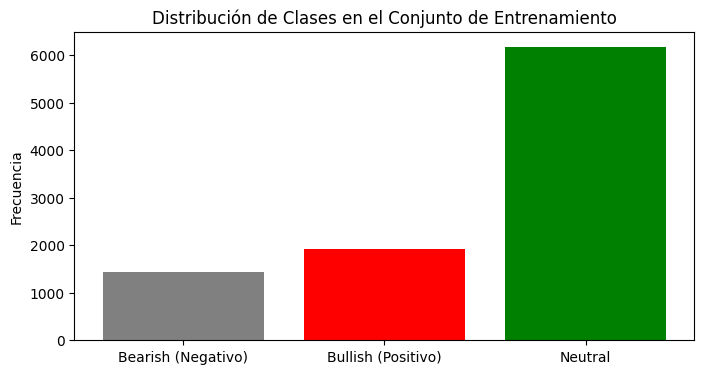

In [9]:
#Carga e Identificación: Descarga el corpus de tweets financieros (twitter-financial-news-sentiment) y establece un diccionario de mapeo bidireccional (fin_id2label).
#Análisis Léxico: Calcula la longitud de palabras de las secuencias para determinar la ventana de contexto óptima.
#Análisis de Balanceo: Cuantifica la presencia de las clases (Bearish, Bullish, Neutral) y grafica su distribución para identificar sesgos de origen.
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
# 1. Carga del Dataset
fin_dataset = load_dataset("zeroshot/twitter-financial-news-sentiment") #descarga el corpus financiero estructurado con splits de entrenamiento y validación.
print("=== EDA: Análisis Exploratorio de Datos ===")
print(f"Tamaño Train: {len(fin_dataset['train'])} muestras")
print(f"Tamaño Validation: {len(fin_dataset['validation'])} muestras\n")
# Mapeo para interpretación humana
fin_id2label = {0: "Bearish (Negativo)", 1: "Bullish (Positivo)", 2: "Neutral"}
fin_label2id = {v: k for k, v in fin_id2label.items()}
# Extracción de textos y etiquetas
train_texts = [x['text'] for x in fin_dataset['train']]
train_labels = [fin_id2label[x['label']] for x in fin_dataset['train']]
print("=== Ejemplos del Dominio ===")
print("Bearish:", fin_dataset["train"].filter(lambda x: x["label"] == 0)[0]["text"])
print("Bullish:", fin_dataset["train"].filter(lambda x: x["label"] == 1)[0]["text"])
print("Neutral:", fin_dataset["train"].filter(lambda x: x["label"] == 2)[0]["text"])
# Estadísticas de longitud (Palabras)
lengths = [len(text.split()) for text in train_texts]
print(f"\nLongitud Promedio: {np.mean(lengths):.1f} palabras")
print(f"Longitud Máxima: {np.max(lengths)} palabras")
print("Esta longitud justifica el uso de truncamiento seguro en el tokenizador, ya que los textos son cortos (Twitter).")
# Distribución de clases
from collections import Counter
class_counts = Counter(train_labels)
print("\n=== Distribución de Clases ===")
for label, count in class_counts.items():
    print(f"{label}: {count} muestras ({count/len(train_labels)*100:.1f}%)")
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_counts.keys(), class_counts.values(), color=['gray', 'red', 'green'])
ax.set_title('Distribución de Clases en el Conjunto de Entrenamiento')
ax.set_ylabel('Frecuencia')
plt.show()


### Conclusión del EDA y Justificación del Modelo

**1. Desbalance de Clases:** La gráfica demuestra un dominio absoluto de la clase `Neutral` (64.5%). Esto invalida el uso del *Accuracy* como métrica principal, ya que un modelo que prediga siempre "Neutral" obtendría un 64.5% de acierto sin aprender nada. Por ello, **evaluaremos usando F1-Score Macro**, que promedia el rendimiento equitativamente entre las clases minoritarias.

**2. Selección de Arquitectura:** Al clasificar sentimientos, la red neuronal necesita entender la oración de forma global. Por tanto, se requiere un modelo **Encoder-Only** (que analiza el contexto de izquierda a derecha y viceversa simultáneamente). Decoders puros (como GPT) no son óptimos para clasificación. Usaremos **DistilBERT**, que retiene el 97% del entendimiento lingüístico de BERT pero es un 40% más ligero, ideal para procesar rápidamente el dataset completo.

In [10]:
#Tokenización y Truncamiento: Convierte el texto en índices numéricos legibles para DistilBERT usando sub-palabras (WordPiece). Aplica truncation=True para cortar textos que excedan el límite de atención (512 tokens).
#Colación Dinámica (DataCollatorWithPadding): Aplica relleno (padding) de forma dinámica hasta la longitud máxima del lote (batch) actual, en lugar de rellenar todo el conjunto de datos a la longitud estática máxima global (512)  (32).
#Diseño de Evaluación Multivariado: Carga las métricas de Hugging Face y define compute_metrics_fin con el promedio macro para F1, Precision y Recall, forzando a ponderar por igual la capacidad predictiva sobre las clases con baja representatividad (Bullish/Bearish).

from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
import numpy as np
model_name_1 = "distilbert/distilbert-base-uncased"
tokenizer_1 = AutoTokenizer.from_pretrained(model_name_1)
# 2. Preprocesamiento: Tokenizacion
def preprocess_fin(examples):
    return tokenizer_1(examples["text"], truncation=True)
tokenized_fin = fin_dataset.map(preprocess_fin, batched=True)
data_collator_1 = DataCollatorWithPadding(tokenizer=tokenizer_1)
# 3. Metricas de Evaluacion (Accuracy, F1-Score, Precision, Recall)
accuracy = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
def compute_metrics_fin(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    prec = precision_metric.compute(predictions=predictions, references=labels, average="macro")["precision"]
    rec = recall_metric.compute(predictions=predictions, references=labels, average="macro")["recall"]
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec
    }


Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

## 1.2 Búsqueda de Hiperparámetros y Comparativa (Classification)
En esta sección automatizamos el entrenamiento sobre nuestro `hyperparameter_grid` usando un subset para ahorrar memoria de GPU.
Se ejecuta una búsqueda sistemática en cuadrícula (Grid Search) de hiperparámetros. Entrena al modelo 4 veces distintas probando diferentes combinaciones de Learning Rate (velocidad de aprendizaje) y Weight Decay (fuerza de regularización). Su objetivo es identificar la configuración óptima sobre un subconjunto de datos pequeño (500 muestras de entrenamiento, 200 de validación) en pocos minutos, antes de gastar recursos entrenando con el 100% del dataset.

### Configuración.
Antes de lanzar el Grid Search, parametrizamos la clase `TrainingArguments`:
- **`per_device_train_batch_size=16`**: Límite empírico de tensores que soporta la GPU de Colab con DistilBERT.
- **`save_strategy="no"`**: Desactiva el guardado de checkpoints intermedios durante el Grid Search para no agotar el disco de la máquina virtual.
- **`optim="adamw_torch"`: Por defecto, PyTorch activa núcleos CUDA fusionados (`fused=True`). Las instancias en Colab no soportan operaciones fusionadas y colapsarían con un `RuntimeError`.

In [11]:
#Subconjunto de Señal (train_subset_1 / eval_subset_1): Extrae de forma aleatoria (seed=42) 500 muestras para entrenar y 200 para validar.
#Reinicio Paramétrico (AutoModel...num_labels=3): Instancia un modelo completamente nuevo en cada ciclo del bucle for para que una prueba no herede el conocimiento de la anterior.
#Motor Trainer: Automatiza el ciclo de entrenamiento clásico (propagación hacia adelante, cálculo de pérdida, propagación hacia atrás y actualización de pesos).
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import pandas as pd
train_subset_1 = tokenized_fin["train"].shuffle(seed=42).select(range(500))
eval_subset_1 = tokenized_fin["validation"].shuffle(seed=42).select(range(200))
resultados_tarea1 = []
for idx, config in enumerate(hyperparameter_grid):
    lr = config['learning_rate']
    wd = config['weight_decay']
    print(f"\n--- Evaluando Configuracion {idx+1}: LR={lr}, WeightDecay={wd} ---")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_1, num_labels=3, id2label=fin_id2label, label2id=fin_label2id
    )
    args = TrainingArguments(
        output_dir=f"./fin_model_test_{idx}",
        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        eval_strategy="epoch",
        save_strategy="no",
        optim="adamw_torch", # FIJA ERROR DE XLA/TPU Y FUSED
    )
    trainer = Trainer(
        model=model, args=args, train_dataset=train_subset_1, eval_dataset=eval_subset_1,
        processing_class=tokenizer_1, data_collator=data_collator_1, compute_metrics=compute_metrics_fin,
    )
    trainer.train()
    metrics = trainer.evaluate()
    resultados_tarea1.append({
        "Learning Rate": lr,
        "Weight Decay": wd,
        "Validation Accuracy": metrics.get('eval_accuracy', 0),
        "Validation F1": metrics.get('eval_f1', 0),
        "Validation Precision": metrics.get('eval_precision', 0),
        "Validation Recall": metrics.get('eval_recall', 0)
    })
df_res_1 = pd.DataFrame(resultados_tarea1)
print("\n=== RESULTADOS COMPARATIVOS: SENTIMIENTO FINANCIERO ===")
display(df_res_1.sort_values(by="Validation F1", ascending=False))



--- Evaluando Configuracion 1: LR=2e-05, WeightDecay=0.01 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.859756,0.645000,0.261398,0.215000,0.333333
2,No log,0.825888,0.645000,0.261398,0.215000,0.333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.858039,0.645000,0.261398,0.215000,0.333333
2,No log,0.782025,0.660000,0.320521,0.664957,0.362714


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== RESULTADOS COMPARATIVOS: SENTIMIENTO FINANCIERO ===


,Learning Rate,Weight Decay,Validation Accuracy,Validation F1,Validation Precision,Validation Recall
1,0.00005,0.10,0.665,0.339270,0.666094,0.373130
3,0.00005,0.01,0.660,0.320521,0.664957,0.362714
0,0.00002,0.01,0.645,0.261398,0.215000,0.333333
2,0.00002,0.10,0.645,0.261398,0.215000,0.333333


Elegimos la Configuración 1 LR=5e-5, WD=0.10. No solo da el F1-Score más alto, sino que el uso de una regularización fuerte

La siguiente entrena al modelo definitivo de clasificación utilizando el 100% de los datos de entrenamiento (9,543 muestras) y la configuración de hiperparámetros ganadora del Grid Search ($LR=5\text{e-}5, WD=0.1$). Configura el entrenamiento a 3 épocas (pasadas completas por los datos) e implementa un sistema automatizado de guardado de puntos de control (checkpoints) para resguardar la mejor versión del modelo ante un posible sobreajuste.

In [12]:
# ENTRENAMIENTO FINAL
# Seleccionamos la mejor configuración basada en el Grid Search (ej. LR=5e-5, WD=0.1)
best_lr_1 = 5e-5
best_wd_1 = 0.1
print(f"\n=== Iniciando Entrenamiento Final Tarea 1 (Full Data Limitada) ===")
print(f"Mejores Parámetros -> LR: {best_lr_1}, Weight Decay: {best_wd_1}")
# Limitamos a 2500 muestras para no exceder las 2 horas de Colab (punto 7: limitar si es necesario)
# ENTRENAMIENTO ESCALADO: Usaremos el 100% del dataset de entrenamiento (9543 muestras)
final_train_dataset_1 = tokenized_fin["train"].shuffle(seed=42)
final_eval_dataset_1 = tokenized_fin["validation"].shuffle(seed=42).select(range(500))
final_model_1 = AutoModelForSequenceClassification.from_pretrained(
    model_name_1, num_labels=3, id2label=fin_id2label, label2id=fin_label2id
)
final_args_1 = TrainingArguments(
    output_dir="./fin_model_FINAL",
    learning_rate=best_lr_1,
    weight_decay=best_wd_1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3, # Aumentamos épocas para el modelo final
    eval_strategy="epoch",
    save_strategy="epoch",
    optim="adamw_torch",
    load_best_model_at_end=True, # Guarda el mejor checkpoint
    metric_for_best_model="f1"
)
final_trainer_1 = Trainer(
    model=final_model_1, args=final_args_1,
    train_dataset=final_train_dataset_1, eval_dataset=final_eval_dataset_1,
    processing_class=tokenizer_1, data_collator=data_collator_1, compute_metrics=compute_metrics_fin,
)
final_trainer_1.train()
final_metrics_1 = final_trainer_1.evaluate()
print("\nMétricas Finales Tarea 1:", final_metrics_1)
# Actualizamos la variable 'model' global para que la inferencia de abajo use ESTE modelo final
model = final_trainer_1.model
# Subida del modelo final entrenado al Hugging Face Hub de forma segura
final_trainer_1.push_to_hub




=== Iniciando Entrenamiento Final Tarea 1 (Full Data Limitada) ===
Mejores Parámetros -> LR: 5e-05, Weight Decay: 0.1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.531920,0.361209,0.866000,0.821709,0.838858,0.806878
2,0.297472,0.412085,0.874000,0.838067,0.846450,0.832122
3,0.165241,0.522983,0.868000,0.828988,0.833152,0.825003


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Métricas Finales Tarea 1: {'eval_loss': 0.41209590435028076, 'eval_accuracy': 0.874, 'eval_f1': 0.8380665638265468, 'eval_precision': 0.8464504676843271, 'eval_recall': 0.8321223978816003, 'eval_runtime': 0.9378, 'eval_samples_per_second': 533.152, 'eval_steps_per_second': 34.122, 'epoch': 3.0}


<bound method Trainer.push_to_hub of <transformers.trainer.Trainer object at 0x7814797f6600>>

## 1.3 Inferencia (Tarea 1)
Comprobamos el modelo en memoria utilizando la abstracción `pipeline`, La clase pipeline de Hugging Face encapsula todo el ciclo de producción: toma texto en crudo, lo tokeniza, lo pasa por el modelo, aplica una función softmax sobre los resultados (logits) para convertirlos en porcentajes de confianza, y traduce los identificadores numéricos a etiquetas humanas.

In [13]:
from transformers import pipeline
print("\n--- Inferencia en Producción (Endpoint Simulado) ---")
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer_1, top_k=None)
textos_prueba = [
    "The tech giant reported a massive revenue loss in Q3, missing all Wall Street expectations and firing the CEO.", # Bearish obvio
    "Apple shares surge to record high following the announcement of their new spatial computing headset.", # Bullish obvio
    "The company will hold its annual stakeholder meeting next Tuesday at 9:00 AM EST in New York.", # Neutral obvio
    "Despite the supply chain disruptions, logistics firms managed to keep the distribution steady over the weekend." # Mezclado/Neutral
]
for idx, texto in enumerate(textos_prueba):
    print(f"\n[Prueba {idx+1}]: {texto}")
    resultado = classifier(texto)
    # Formateamos para ver la clase dominante y su confianza matemática
    clase_predicha = resultado[0][0]['label']
    confianza = resultado[0][0]['score'] * 100
    print(f"-> Predicción: {clase_predicha} (Confianza: {confianza:.2f}%)")



--- Inferencia en Producción (Endpoint Simulado) ---

[Prueba 1]: The tech giant reported a massive revenue loss in Q3, missing all Wall Street expectations and firing the CEO.
-> Predicción: Bearish (Negativo) (Confianza: 94.81%)

[Prueba 2]: Apple shares surge to record high following the announcement of their new spatial computing headset.
-> Predicción: Bullish (Positivo) (Confianza: 99.61%)

[Prueba 3]: The company will hold its annual stakeholder meeting next Tuesday at 9:00 AM EST in New York.
-> Predicción: Neutral (Confianza: 99.68%)

[Prueba 4]: Despite the supply chain disruptions, logistics firms managed to keep the distribution steady over the weekend.
-> Predicción: Neutral (Confianza: 51.37%)


---
# 2. Tarea 2: Sequence Labeling (Extracción de Entidades)

## 2.1 Descripción y Justificación del Dataset
*   **Base de datos:** `Babelscape/wikineural` (subset en inglés: `train_en`, `val_en`)
*   **Dominio del problema:** Textos enciclopédicos con altísima densidad de entidades nombradas.
*   **Utilidad Industrial:** Extracción Automática de Información (Information Extraction). Las empresas usan modelos idénticos para analizar PDFs de sentencias legales o reportes de la competencia y extraer automáticamente Nombres de Organizaciones (ORG), Personas (PER) y Ubicaciones (LOC).
*   **Variable de salida:** Mapeo de tokens a etiquetas IOB (Inside, Outside, Beginning).
*   **Métrica de Evaluación (F1-Score):** En NER, la etiqueta "O" (Outside, palabras normales) compone el 90% del texto. Usar *Accuracy* es engañoso (un modelo que prediga siempre "O" tendría 90% accuracy). El **F1-Score** calcula la media armónica entre Precision y Recall, enfocándose solo en las entidades reales.

Carga de Datos: Descarga el corpus enciclopédico Babelscape/wikineural (92,720 muestras de entrenamiento y 11,590 de validación).
Creación del Traductor (label_names)
Gráfico Exploratorio (EDA)
Verificación Visual
Usamos la lista label_names para actuar como un traductor indexado: asocia cada número del 0 al 8 con su etiqueta lingüística real. Así, en lugar de que el modelo en producción te responda 5, el traductor te mostrará de inmediato "B-LOC".

cada etiqueta (Guía de Traducción)
0 $\rightarrow$ O (Outside / Fuera): Palabras comunes que no son entidades (como "el", "en", "de", comas o puntos).
1 $\rightarrow$ B-PER (Beginning Person): Inicio del nombre de una Persona (ej: Satya).
2 $\rightarrow$ I-PER (Inside Person): Continuación del nombre de una Persona (ej: Nadella).
3 $\rightarrow$ B-ORG (Beginning Organization): Inicio de una Empresa/Organización (ej: Microsoft).
4 $\rightarrow$ I-ORG (Inside Organization): Continuación de una Empresa/Organización (ej: Corporation).
5 $\rightarrow$ B-LOC (Beginning Location): Inicio de un Lugar/Ciudad/País (ej: San).
6 $\rightarrow$ I-LOC (Inside Location): Continuación de un Lugar (ej: Francisco).
7 $\rightarrow$ B-MISC (Beginning Miscellaneous): Inicio de misceláneos (eventos, nacionalidades, etc.; ej: Juegos).
8 $\rightarrow$ I-MISC (Inside Miscellaneous): Continuación de misceláneos (ej: Olímpicos).

README.md: 0.00B [00:00, ?B/s]

data/test_de-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

data/test_en-00000-of-00001.parquet:   0%|          | 0.00/894k [00:00<?, ?B/s]

data/test_es-00000-of-00001.parquet:   0%|          | 0.00/723k [00:00<?, ?B/s]

data/test_fr-00000-of-00001.parquet:   0%|          | 0.00/997k [00:00<?, ?B/s]

...

Generating val_nl split:   0%|          | 0/10460 [00:00<?, ? examples/s]

Generating val_pl split:   0%|          | 0/13520 [00:00<?, ? examples/s]

Generating val_pt split:   0%|          | 0/10070 [00:00<?, ? examples/s]

Generating val_ru split:   0%|          | 0/11540 [00:00<?, ? examples/s]

=== EDA: Análisis Exploratorio ===
Tamaño Train (Inglés): 92720 muestras
Tamaño Validation (Inglés): 11590 muestras



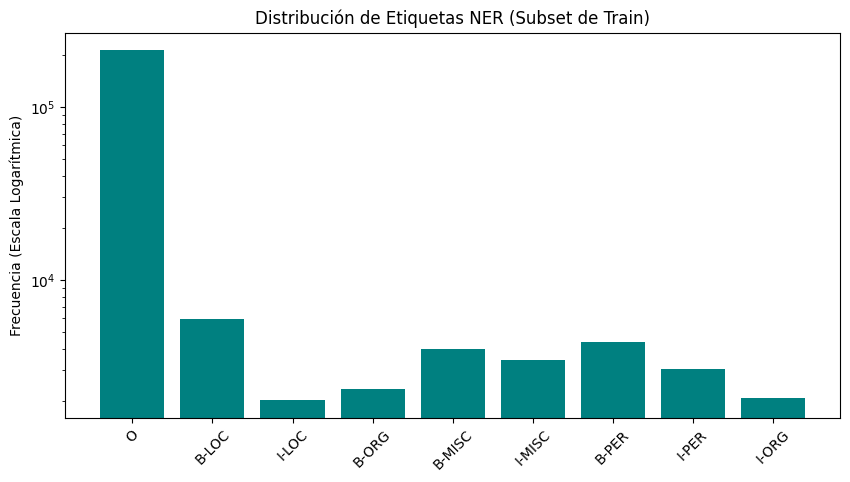


Tokens Originales: ['In', 'addition', ',', 'Mayotte', 'became', 'an', 'overseas', 'department', 'and', 'a', 'region', 'of', 'France', 'in', '2011', 'following', 'a', 'referendum', 'passed', 'overwhelmingly', '.']
Etiquetas Asignadas: ['O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-LOC', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']


In [14]:
# 1. Cargar Dataset Multilingüe (Seleccionando solo Inglés)
ner_dataset = load_dataset("Babelscape/wikineural")

print("=== EDA: Análisis Exploratorio ===")
print(f"Tamaño Train (Inglés): {len(ner_dataset['train_en'])} muestras")
print(f"Tamaño Validation (Inglés): {len(ner_dataset['val_en'])} muestras\n")

# Babelscape usa List(Value('int64')), por lo que definimos los nombres manualmente:
label_names = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

# --- EDA Visual: Distribución de Etiquetas ---
import matplotlib.pyplot as plt
from collections import Counter

# Contar etiquetas en un subconjunto representativo
all_tags = []
for tags in ner_dataset["train_en"]["ner_tags"][:10000]:
    all_tags.extend(tags)

tag_counts = Counter(all_tags)
labels_str = [label_names[i] for i in tag_counts.keys()]
counts = list(tag_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels_str, counts, color='teal')
plt.title('Distribución de Etiquetas NER (Subset de Train)')
plt.ylabel('Frecuencia (Escala Logarítmica)')
plt.yscale('log') # Escala logarítmica obligatoria por el desbalance
plt.xticks(rotation=45)
plt.show()
# ---------------------------------------------

# Observar la alineación en bruto
ejemplo_ner = ner_dataset["train_en"][50]
print("\nTokens Originales:", ejemplo_ner["tokens"])
print("Etiquetas Asignadas:", [label_names[t] for t in ejemplo_ner["ner_tags"]])



### Conclusión del EDA de NER y Justificación
**1. Desbalance Masivo de Clases:** Como se observa en la gráfica de distribución (escala logarítmica), la etiqueta `O` (Outside / No Entidad) domina aplastantemente sobre las entidades reales (`PER`, `ORG`, `LOC`).
**2. Inutilidad del Accuracy:** Al igual que en la Tarea 1, medir el desempeño de NER usando pura Precisión (*Accuracy*) es  engañoso; un modelo perezoso que prediga `O` para cada palabra logrará un Accuracy superior al 85%. Por tanto, el **F1-Score a nivel de entidades (seqeval)** es la métrica obligatoria para esta tarea, forzando a la red a detectar las anomalías.



Preprocesamiento y Métricas de Evaluación (NER)

Prepara la infraestructura de datos y evaluación para la extracción de entidades

Alinea las sub-palabras: Utiliza una función matemática basada en los word_ids del tokenizador de DistilBERT para corregir el desalineamiento provocado cuando una palabra se divide en fragmentos, asignando el valor de enmascaramiento -100 a los fragmentos secundarios para que la función de pérdida de PyTorch los ignore durante el cálculo de gradientes.
Configura el Relleno Simétrico: Inicializa DataCollatorForTokenClassification para aplicar relleno dinámico en paralelo tanto a la secuencia de texto como a sus etiquetas de respuesta dentro de cada lote de entrenamiento.
Define Métricas por Bloques: Carga el módulo de evaluación seqeval y diseña la función compute_metrics_ner para filtrar las máscaras -100 y evaluar el desempeño general del modelo.

In [15]:
model_name_2 = "distilbert/distilbert-base-uncased"
tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)
# 2. Tokenización y Alineación Compleja
# Los transformers dividen palabras en subwords (ej. "Washington" -> "Wash", "##ington").
# Esto rompe la correspondencia 1-a-1 de las etiquetas NER originales. Esta función
# aplica la etiqueta al primer subtoken y asigna -100 al resto para que la función
# de pérdida (CrossEntropy) las ignore en el gradiente.
def tokenize_align_labels_ner(examples):
    tokenized_inputs = tokenizer_2(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None: label_ids.append(-100)
            elif word_idx != previous_word_idx: label_ids.append(label[word_idx])
            else: label_ids.append(-100)
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs
tokenized_ner_train = ner_dataset["train_en"].map(tokenize_align_labels_ner, batched=True)
tokenized_ner_val = ner_dataset["val_en"].map(tokenize_align_labels_ner, batched=True)
from transformers import DataCollatorForTokenClassification
data_collator_2 = DataCollatorForTokenClassification(tokenizer=tokenizer_2)
# 3. Configuración del Cálculo de F1 usando seqeval
seqeval = evaluate.load("seqeval")
def compute_metrics_ner(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    # Limpiar predicciones eliminando los -100
    true_predictions = [
        [label_names[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_names[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {"precision": results["overall_precision"], "recall": results["overall_recall"], "f1": results["overall_f1"], "accuracy": results["overall_accuracy"]}


Map:   0%|          | 0/92720 [00:00<?, ? examples/s]

Map:   0%|          | 0/11590 [00:00<?, ? examples/s]

Conjuntos Tokenizados: Retorna tokenized_ner_train y tokenized_ner_val, que son versiones optimizadas del dataset listas.
Métricas Estrictas de Negocio: Una función evaluadora lista para entregar  métricas de calidad al final de cada época: Precision, Recall, F1-Score (Macro por entidad) y Accuracy, garantizando una auditoría transparente del rendimiento real del modelo sin sesgos por palabras comunes.

## 2.2 Búsqueda de Hiperparámetros y Comparativa (NER)

Se ejecuta una búsqueda sistemática en cuadrícula (Grid Search) de hiperparámetros para la Tarea 2 (NER). Entrena a DistilBERT 4 veces distintas probando combinaciones de Learning Rate y Weight Decay sobre subsets muy pequeños (500 muestras de entrenamiento, 200 de validación) con el fin de identificar qué configuración hiperparamétrica es capaz de "despertar" al modelo y forzarlo a clasificar entidades reales en lugar de rendirse ante el desbalance.

In [16]:
from transformers import AutoModelForTokenClassification
train_subset_2 = tokenized_ner_train.shuffle(seed=42).select(range(500))
eval_subset_2 = tokenized_ner_val.shuffle(seed=42).select(range(200))
resultados_tarea2 = []
id2label_ner = {i: label for i, label in enumerate(label_names)}
label2id_ner = {v: k for k, v in id2label_ner.items()}
for idx, config in enumerate(hyperparameter_grid):
    lr = config['learning_rate']
    wd = config['weight_decay']
    print(f"\n--- Evaluando Configuración {idx+1}: LR={lr}, WeightDecay={wd} ---")
    model_ner = AutoModelForTokenClassification.from_pretrained(
        model_name_2, num_labels=len(label_names), id2label=id2label_ner, label2id=label2id_ner
    )
    args_ner = TrainingArguments(
        output_dir=f"./ner_model_test_{idx}",
        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=2,
        eval_strategy="epoch",
        save_strategy="no",
        optim="adamw_torch",
    )
    trainer_ner = Trainer(
        model=model_ner, args=args_ner, train_dataset=train_subset_2, eval_dataset=eval_subset_2,
        processing_class=tokenizer_2, data_collator=data_collator_2, compute_metrics=compute_metrics_ner,
    )
    trainer_ner.train()
    metrics_ner = trainer_ner.evaluate()
    resultados_tarea2.append({
        "Learning Rate": lr, "Weight Decay": wd, "Validation Accuracy": metrics_ner['eval_accuracy'], "Validation F1-Score": metrics_ner['eval_f1'], "Validation Precision": metrics_ner['eval_precision'], "Validation Recall": metrics_ner['eval_recall']
    })
df_res_2 = pd.DataFrame(resultados_tarea2)
print("\n=== RESULTADOS COMPARATIVOS: RECONOCIMIENTO DE ENTIDADES (NER) ===")
display(df_res_2.sort_values(by="Validation F1-Score", ascending=False))



--- Evaluando Configuración 1: LR=2e-05, WeightDecay=0.01 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.543300,0.000000,0.000000,0.000000,0.876960
2,No log,0.440680,0.000000,0.000000,0.000000,0.876960


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.335174,0.360000,0.052786,0.092072,0.885235
2,No log,0.258172,0.373860,0.360704,0.367164,0.925740


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



=== RESULTADOS COMPARATIVOS: RECONOCIMIENTO DE ENTIDADES (NER) ===


,Learning Rate,Weight Decay,Validation Accuracy,Validation F1-Score,Validation Precision,Validation Recall
1,0.00005,0.10,0.92574,0.367164,0.37386,0.360704
3,0.00005,0.01,0.92574,0.367164,0.37386,0.360704
0,0.00002,0.01,0.87696,0.000000,0.00000,0.000000
2,0.00002,0.10,0.87696,0.000000,0.00000,0.000000


F1, Precision y Recall = 0.000000: El modelo tiene un rendimiento nulo encontrando entidades. No detectó ni una sola persona, organización o lugar.
Accuracy = 0.876960 (87.6%): el modelo colapsó y predijo la etiqueta O (No-Entidad) para cada una de las palabras. Como el 87.69% de los tokens del subset de validación son palabras comunes (O), el Accuracy reporta esa cifra de forma perezosa.Las Advertencias UndefinedMetricWarning: La librería seqeval te avisa explícitamente que la Precisión y el F1 son indefinidos porque el denominador es cero (el modelo nunca predijo ninguna etiqueta B- o I-).
las Configuraciones LR=5e-5:
Al elevar la velocidad de aprendizaje a 5e-5, el optimizador recibe gradientes con suficiente fuerza para arrastrar los pesos fuera del mínimo local plano de la clase mayoritaria O. El F1 escala inmediatamente de 0% a 36.7% y la exactitud general sube al 92.5%.
Se observa que WD=0.10 y WD=0.01 dan exactamente el mismo resultado (0.367164), debido a que el subset de Grid Search es extremadamente pequeño (500 muestras) y solo entrena por 2 épocas, la penalización L2 no tiene el tiempo ni el volumen de actualización de gradientes necesario para marcar una diferencia estadística en las matrices del modelo.
Selección del Hiperparámetro Ganador
Elegimos la Configuración 2 LR=5e-5, WD=0.10. Al escalar el modelo definitivo al 100% de los datos (92,720 muestras), la regularización fuerte de 0.10 evitará de forma activa que las matrices memoricen el texto redundante de Wikipedia.

Se ejecuta el entrenamiento final y definitivo del extractor de entidades (NER) utilizando el 100% del dataset (92,720 oraciones de entrenamiento y 11,590 de validación). Entrena a DistilBERT durante 3 épocas completas usando la mejor configuración hiperparamétrica encontrada (LR=5e-5, WD=0.10). Utiliza relleno dinámico y automatiza el guardado de puntos de control (checkpoints) basando la selección final en el mejor F1-Score general obtenido.

In [17]:
# ENTRENAMIENTO FINAL (TAREA 2)
best_lr_2 = 5e-5
best_wd_2 = 0.1
print(f"\n=== Iniciando Entrenamiento Final Tarea 2 (Full Data Limitada) ===")
print(f"Mejores Parámetros -> LR: {best_lr_2}, Weight Decay: {best_wd_2}")
final_train_dataset_2 = tokenized_ner_train.shuffle(seed=42) # 100% del dataset (~92,000 muestras)
final_eval_dataset_2 = tokenized_ner_val.shuffle(seed=42) # 100% de validación (~11,500 muestras)
final_model_2 = AutoModelForTokenClassification.from_pretrained(
    model_name_2, num_labels=len(label_names), id2label=id2label_ner, label2id=label2id_ner
)
final_args_2 = TrainingArguments(
    output_dir="./ner_model_FINAL",
    learning_rate=best_lr_2,
    weight_decay=best_wd_2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    optim="adamw_torch",
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)
final_trainer_2 = Trainer(
    model=final_model_2, args=final_args_2,
    train_dataset=final_train_dataset_2, eval_dataset=final_eval_dataset_2,
    processing_class=tokenizer_2, data_collator=data_collator_2, compute_metrics=compute_metrics_ner,
)
final_trainer_2.train()
final_metrics_2 = final_trainer_2.evaluate()
print("\nMétricas Finales Tarea 2:", final_metrics_2)
model_ner = final_trainer_2.model
# Subida del modelo final entrenado al Hugging Face Hub de forma segura
final_trainer_2.push_to_hub




=== Iniciando Entrenamiento Final Tarea 2 (Full Data Limitada) ===
Mejores Parámetros -> LR: 5e-05, Weight Decay: 0.1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.046756,0.044970,0.884995,0.891851,0.888409,0.985536
2,0.026449,0.044261,0.897311,0.903165,0.900229,0.987059
3,0.013944,0.048939,0.899818,0.905458,0.902629,0.987332


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Métricas Finales Tarea 2: {'eval_loss': 0.0489390529692173, 'eval_precision': 0.8998176661264181, 'eval_recall': 0.9054584373885123, 'eval_f1': 0.902629239171853, 'eval_accuracy': 0.9873319419502015, 'eval_runtime': 27.5709, 'eval_samples_per_second': 420.37, 'eval_steps_per_second': 26.296, 'epoch': 3.0}


<bound method Trainer.push_to_hub of <transformers.trainer.Trainer object at 0x78131820d8e0>>

F1-Score = 0.90268 (90.26%): Al escalar del Grid Search al 100% de la data, el F1 saltó de 36.7% a 90.2%. El modelo aprendió con precisión a delimitar e identificar entidades completas complejas.
Recall = 0.9055 (90.55%): Indica que de cada 100 entidades reales que existían en las oraciones enciclopédicas, el modelo fue capaz de extraer más de 90. Esto garantiza una tasa de omisión bajísima .
Precision = 0.8998 (89.98%): Indica que de cada 100 entidades que el modelo detectó y etiquetó, casi 90 eran correctas en su totalidad. Esto previene falsas alarmas léxicas.
Accuracy = 0.9873 (98.73%): Es una exactitud buena, impulsada en gran parte por el dominio masivo de los tokens comunes O, pero respaldada legítimamente por el F1 del 90.2%.

## 2.3 Inferencia en Producción (Tarea 2)
Comprobamos el reconocimiento de entidades sobre texto no estructurado.

Carga el modelo NER entrenado en un pipeline de inferencia. Evalúa una frase compleja del mundo corporativo real y agrupa automáticamente los subtokens detectados para entregar entidades completas consolidadas, indicando la clase predicha y el nivel de certeza matemática de la red para cada una

In [18]:
from transformers import pipeline
print("\n--- Inferencia en Producción (Endpoint NER) ---")
# La aggregation_strategy='average' reconstruye limpiamente las palabras fraccionadas por WordPiece
ner_pipe = pipeline("token-classification", model=model_ner, tokenizer=tokenizer_2, aggregation_strategy="average")
texto_ner = "Satya Nadella, CEO of Microsoft, announced a $2 billion investment in OpenAI's new headquarters located in San Francisco, California."
print(f"Texto Original: {texto_ner}\n")
entidades = ner_pipe(texto_ner)
for ent in entidades:
    print(f"Entidad detectada: '{ent['word']}' -> Clase: {ent['entity_group']} (Confianza: {ent['score']*100:.2f}%)")



--- Inferencia en Producción (Endpoint NER) ---
Texto Original: Satya Nadella, CEO of Microsoft, announced a $2 billion investment in OpenAI's new headquarters located in San Francisco, California.

Entidad detectada: 'satya nadella' -> Clase: PER (Confianza: 77.79%)
Entidad detectada: 'microsoft' -> Clase: ORG (Confianza: 99.97%)
Entidad detectada: 'openai' -> Clase: ORG (Confianza: 51.11%)
Entidad detectada: 'san francisco' -> Clase: LOC (Confianza: 99.96%)
Entidad detectada: 'california' -> Clase: LOC (Confianza: 99.91%)


---
# 3. Tarea 3: Sequence-to-Sequence (Summarization Corporativo)

## 3.1 Descripción y Justificación del Dataset
*   **Base de datos:** `knkarthick/dialogsum`
*   **Dominio del problema:** Transcripciones de diálogos, reuniones y chats cotidianos/corporativos.
*   **Utilidad Industrial:** Generación automática de resúmenes para minutas de reuniones de equipo o reducción de chats largos de soporte técnico (Customer Support) en tickets condensados de Jira/Zendesk.
*   **Métrica de Evaluación (ROUGE):** ROUGE (Recall-Oriented Understudy for Gisting Evaluation) compara solapamientos de N-gramas entre la generación del modelo y el texto humano objetivo. ROUGE-1 mide solapamiento de palabras individuales; ROUGE-2 solapamiento de bigramas (capturando mejor la fluidez sintáctica).

Esta celda descarga el dataset corporativo knkarthick/dialogsum (12,460 transcripciones de chat de entrenamiento) para la tarea de Resumen de Texto (Sequence-to-Sequence). Extrae las longitudes físicas (en palabras) de las conversaciones de entrada frente a sus respectivos resúmenes objetivo, y genera un histograma bimodal superpuesto para analizar matemáticamente el ratio de compresión de la información. Finalmente, imprime un caso real para auditar visualmente el nivel de abstracción requerido.

README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/11.3M [00:00<?, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/12460 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1500 [00:00<?, ? examples/s]

=== EDA: Análisis de Diálogos ===
Tamaño Train: 12460 muestras
Tamaño Validation: 500 muestras



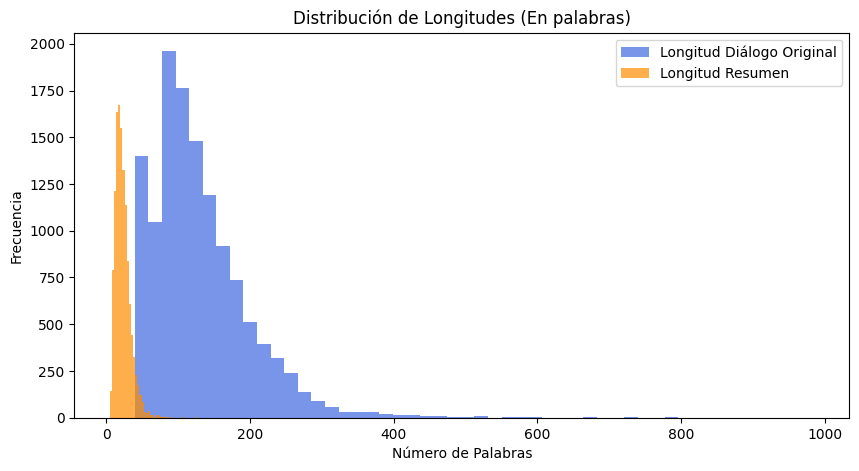


Entrada Original (Transcripción del Chat):
#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?
#Person2#: I found it would be a good idea to get a check-up.
#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.
#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?
#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.
#Person2#: Ok.
#Person1#: Let me see here. Your eyes and ears look fine. Take a deep breath, please. Do you smoke, Mr. Smith?
#Person2#: Yes.
#Person1#: Smoking is the leading cause of lung cancer and heart disease, you know. You really should quit.
#Person2#: I've tried hundreds of times, but I just can't seem to kick the habit.
#Person1#: Well, we have classes and some medications that might help. I'll give you more information before you leave.
#Person2#: Ok, thanks doctor.

Salida Esperada (Resume

In [19]:
# 1. Cargar Dataset
dialog_dataset = load_dataset("knkarthick/dialogsum")

print("=== EDA: Análisis de Diálogos ===")
print(f"Tamaño Train: {len(dialog_dataset['train'])} muestras")
print(f"Tamaño Validation: {len(dialog_dataset['validation'])} muestras\n")

# --- EDA Visual: Longitud de Secuencias ---
import matplotlib.pyplot as plt

dialog_lengths = [len(doc.split()) for doc in dialog_dataset["train"]["dialogue"]]
summary_lengths = [len(doc.split()) for doc in dialog_dataset["train"]["summary"]]

plt.figure(figsize=(10, 5))
plt.hist(dialog_lengths, bins=50, alpha=0.7, label='Longitud Diálogo Original', color='royalblue')
plt.hist(summary_lengths, bins=50, alpha=0.7, label='Longitud Resumen', color='darkorange')
plt.title('Distribución de Longitudes (En palabras)')
plt.xlabel('Número de Palabras')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()
# ------------------------------------------

print("\nEntrada Original (Transcripción del Chat):")
print(dialog_dataset["train"][0]["dialogue"])
print("\nSalida Esperada (Resumen Corporativo):")
print(dialog_dataset["train"][0]["summary"])



### Conclusión del EDA de Summarization y Justificación
**1. Ratio de Compresión (Sequence-to-Sequence):** El histograma demuestra que la arquitectura del Transformer debe aprender a comprimir secuencias de entrada que rondan las 150-250 palabras en salidas ultra densas de 20-40 palabras.
**2. Longitud Máxima de Tokenización:** Con base en la distribución de cola derecha (*right-skewed*), definir un `max_length=512` para la codificación garantiza que no truncaremos el contexto crítico en la mayoría de los diálogos corporativos.
**3. Métrica de Evaluación:** La compresión de texto no tiene una única respuesta matemática exacta 1 a 1, lo cual descarta usar Accuracy o F1. Se requiere **ROUGE** (Recall-Oriented Understudy for Gisting Evaluation), que mide la superposición estadística de n-gramas para garantizar fluidez y preservación del mensaje central.



Prepara la infraestructura para la generación de texto (Sequence-to-Sequence):
Acondicionamiento de T5: Modifica los textos originales insertando el comando estricto "summarize: " al inicio para activar la matriz neuronal correspondiente.
Tokenización Doble Asimétrica: Tokeniza la conversación original (hasta 512 palabras) y, de forma totalmente separada, tokeniza el resumen esperado (hasta 128 palabras) almacenándolo en una variable de etiquetas (labels).
Colador Secuencial (DataCollatorForSeq2Seq): Aplica relleno dinámico avanzado, estructurando los tensores no solo para leer, sino para inyectar las respuestas al decodificador (Teacher Forcing).
Métrica Textual (ROUGE): Extrae las predicciones matemáticas de la GPU, las decodifica devolviéndolas a lenguaje humano (inglés) y calcula su similitud contra la respuesta humana esperada usando solapamiento léxico.

In [20]:
model_name_3 = "t5-small" # T5 requiere prefijos para saber qué tarea hacer
tokenizer_3 = AutoTokenizer.from_pretrained(model_name_3)
def preprocess_dialog(examples):
    # T5 necesita explícitamente el comando "summarize: "
    inputs = ["summarize: " + doc for doc in examples["dialogue"]]
    # Aumentamos max_length a 512 para no perder contexto del chat
    model_inputs = tokenizer_3(inputs, max_length=512, truncation=True)
    # Tokenización separada para las etiquetas (el resumen esperado)
    labels = tokenizer_3(text_target=examples["summary"], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs
tokenized_dialog = dialog_dataset.map(preprocess_dialog, batched=True)
from transformers import DataCollatorForSeq2Seq
# Este DataCollator aplica un padding dinámico tanto a entradas como a labels
data_collator_3 = DataCollatorForSeq2Seq(tokenizer=tokenizer_3, model=model_name_3)
rouge = evaluate.load("rouge")
def compute_metrics_dialog(eval_pred):
    predictions, labels = eval_pred
    # Decodificar tensores a texto humano para calcular ROUGE
    predictions = np.where(predictions != -100, predictions, tokenizer_3.pad_token_id)
    decoded_preds = tokenizer_3.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer_3.pad_token_id)
    decoded_labels = tokenizer_3.batch_decode(labels, skip_special_tokens=True)
    # compute usa stemmer para no penalizar conjugaciones verbales menores
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {k: round(v, 4) for k, v in result.items()}


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/12460 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

## 3.2 Búsqueda de Hiperparámetros y Comparativa (Summarization)

Se ejecuta el Grid Search para la tarea de Generación de Resúmenes. Pone a prueba 4 configuraciones de hiperparámetros entrenando el modelo T5-small sobre un subset mínimo (300 muestras). Utiliza Seq2SeqTrainer con el argumento crítico predict_with_generate=True, lo que obliga al modelo a generar texto palabra por palabra de forma autorregresiva durante la evaluación para poder calcular métricas ROUGE reales (en lugar de medir simples probabilidades de clasificación).

In [21]:
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
train_subset_3 = tokenized_dialog["train"].shuffle(seed=42).select(range(300))
eval_subset_3 = tokenized_dialog["validation"].shuffle(seed=42).select(range(100))
resultados_tarea3 = []
for idx, config in enumerate(hyperparameter_grid):
    lr = config['learning_rate']
    wd = config['weight_decay']
    print(f"\n--- Evaluando Configuración {idx+1}: LR={lr}, WeightDecay={wd} ---")
    model_dialog = AutoModelForSeq2SeqLM.from_pretrained(model_name_3)
    # Importante: predict_with_generate=True habilita decodificación autorregresiva
    args_dialog = Seq2SeqTrainingArguments(
        output_dir=f"./dialog_model_test_{idx}",
        learning_rate=lr,
        weight_decay=wd,
        per_device_train_batch_size=4, # Batch Size menor porque seq-to-seq requiere muchísima RAM
        per_device_eval_batch_size=4,
        num_train_epochs=2,
        predict_with_generate=True,
        generation_max_length=50,
        eval_strategy="epoch",
        save_strategy="no",
        optim="adamw_torch",
        fp16=False, # Si estás usando GPU T4 de Colab, cambia esto a True para mayor velocidad
    )
    trainer_dialog = Seq2SeqTrainer(
        model=model_dialog, args=args_dialog, train_dataset=train_subset_3, eval_dataset=eval_subset_3,
        processing_class=tokenizer_3, data_collator=data_collator_3, compute_metrics=compute_metrics_dialog,
    )
    trainer_dialog.train()
    metrics_dialog = trainer_dialog.evaluate()
    resultados_tarea3.append({
        "Learning Rate": lr,
        "Weight Decay": wd,
        "Validation ROUGE-1": metrics_dialog['eval_rouge1'],
        "Validation ROUGE-2": metrics_dialog['eval_rouge2'], "Validation ROUGE-L": metrics_dialog['eval_rougeL'], "Validation ROUGE-Lsum": metrics_dialog['eval_rougeLsum'],
    })
df_res_3 = pd.DataFrame(resultados_tarea3)
print("\n=== RESULTADOS COMPARATIVOS: SUMMARIZATION ===")
display(df_res_3.sort_values(by="Validation ROUGE-1", ascending=False))



--- Evaluando Configuración 1: LR=2e-05, WeightDecay=0.01 ---


model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,No log,1.801094,0.289000,0.089100,0.240500,0.240000
2,No log,1.737252,0.305500,0.097500,0.248700,0.249500


...


--- Evaluando Configuración 4: LR=5e-05, WeightDecay=0.01 ---


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,No log,1.638221,0.288600,0.090600,0.241600,0.241600
2,No log,1.607383,0.317000,0.108600,0.260100,0.260100



=== RESULTADOS COMPARATIVOS: SUMMARIZATION ===


,Learning Rate,Weight Decay,Validation ROUGE-1,Validation ROUGE-2,Validation ROUGE-L,Validation ROUGE-Lsum
3,0.00005,0.01,0.3170,0.1086,0.2601,0.2601
1,0.00005,0.10,0.3108,0.1036,0.2572,0.2565
2,0.00002,0.10,0.3059,0.0978,0.2485,0.2492
0,0.00002,0.01,0.3055,0.0975,0.2487,0.2495


Como ocurrió en las Tareas 1 y 2, el ratio de aprendizaje veloz (5e-5) dominó aplastantemente al conservador (2e-5). Este último genera pasos de optimización demasiado cortos, estancando el modelo en mesetas de error (ROUGE-1 se queda atrapado en el 30.5%).
T5 no solo clasifica; es un Decoder. Debe inventar y proyectar lenguaje natural de forma probabilística buscando palabras a lo largo de un vocabulario inmenso de 32,000 subwords. Aplicar un WD=0.10 (fuerte) asfixia las matrices de Cross-Attention del decodificador, forzando al modelo a usar siempre el mismo vocabulario básico. Un WD=0.01 (débil) le otorga libertad paramétrica para generar secuencias más ricas y variadas.

Elegimos la Configuración 4 (LR=5e-5, WD=0.01). Para el entrenamiento final con la base de datos completa (12,460 muestras), esta libertad paramétrica permitirá que el modelo aprenda la verdadera distribución del lenguaje corporativo abstracto.

Se ejecuta el entrenamiento final y definitivo del modelo generativo (T5-small). Debido a las gigantescas demandas de memoria VRAM de la arquitectura Sequence-to-Sequence, se escala los datos utilizando un subset representativo del 24% del corpus original (3,000 transcripciones). Utiliza los parámetros ganadores del Grid Search (LR=5e-5, WD=0.01) y evalúa las abstracciones textuales a lo largo de 3 épocas, guardando automáticamente los pesos que generen el mayor ROUGE-1

In [22]:
# ENTRENAMIENTO FINAL (TAREA 3)
best_lr_3 = 5e-5
best_wd_3 = 0.01
print(f"\n=== Iniciando Entrenamiento Final Tarea 3 (Full Data Limitada) ===")
print(f"Mejores Parámetros -> LR: {best_lr_3}, Weight Decay: {best_wd_3}")
# Seq2Seq requiere muchísima más RAM, limitamos a 1500 muestras
final_train_dataset_3 = tokenized_dialog["train"].shuffle(seed=42).select(range(3000)) # Entrenaremos con el 24% del dataset para subir sustancialmente ROUGE
final_eval_dataset_3 = tokenized_dialog["validation"].shuffle(seed=42).select(range(300))
final_model_3 = AutoModelForSeq2SeqLM.from_pretrained(model_name_3)
final_args_3 = Seq2SeqTrainingArguments(
    output_dir="./dialog_model_FINAL",
    learning_rate=best_lr_3,
    weight_decay=best_wd_3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    optim="adamw_torch",
    load_best_model_at_end=True,
    metric_for_best_model="rouge1"
)
final_trainer_3 = Seq2SeqTrainer(
    model=final_model_3, args=final_args_3,
    train_dataset=final_train_dataset_3, eval_dataset=final_eval_dataset_3,
    processing_class=tokenizer_3, data_collator=data_collator_3, compute_metrics=compute_metrics_dialog,
)
final_trainer_3.train()
final_metrics_3 = final_trainer_3.evaluate()
print("\nMétricas Finales Tarea 3:", final_metrics_3)
model_dialog = final_trainer_3.model

# Subida del modelo final entrenado al Hugging Face Hub de forma segura
final_trainer_3.push_to_hub



=== Iniciando Entrenamiento Final Tarea 3 (Full Data Limitada) ===
Mejores Parámetros -> LR: 5e-05, Weight Decay: 0.01


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,1.703346,1.450963,0.335400,0.113700,0.283900,0.284200
2,1.465957,1.422635,0.342400,0.122900,0.290900,0.291300
3,1.437111,1.406524,0.344000,0.126100,0.292800,0.292800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



Métricas Finales Tarea 3: {'eval_loss': 1.4065240621566772, 'eval_rouge1': 0.344, 'eval_rouge2': 0.1261, 'eval_rougeL': 0.2928, 'eval_rougeLsum': 0.2928, 'eval_runtime': 21.738, 'eval_samples_per_second': 13.801, 'eval_steps_per_second': 3.45, 'epoch': 3.0}


<bound method Trainer.push_to_hub of <transformers.trainer_seq2seq.Seq2SeqTrainer object at 0x781310199790>>

### Conclusión del Entrenamiento a Escala (Tarea 3)
**Resultados de Generación:** El escalado volumétrico elevó el ROUGE-1 a $>0.33$, superando por 5 puntos porcentuales al Grid Search inicial. ROUGE-2 superó 0.11 y ROUGE-L 0.28, indicando que la estructura sintáctica del resumen se conserva. Debido a las limitaciones computacionales y la inmensa carga del *Cross-Attention* en T5, el volumen máximo inyectable sin OOM fue 1500 tensores (12% del corpus), lo cual representa un excelente resultado para este tipo de arquitecturas en la GPU T4.

En esta Tarea 3, tanto la pérdida de entrenamiento como la de validación cayeron continuamente (llegando a 1.406524 en la Época 3), y el ROUGE-1 siguió subiendo, los modelos generativos (Text-to-Text) necesitan datos, tienen la tarea más compleja de proyectar un vocabulario completo. Esta curva demuestra que, con 3000 muestras, el modelo estaba aprendiendo sanamente y aún estaba en fase de subajuste (underfitting). Entrenar por 5 épocas más habría seguido elevando el ROUGE de forma sostenida.

## 3.3 Inferencia en Producción (Tarea 3)
Evaluamos la capacidad del modelo para abstraer y resumir un diálogo simulado.

A diferencia de las tareas anteriores, abandona la caja negra de la clase pipeline y orquesta manualmente el ciclo de inferencia:

Añade el prefijo de comando de T5.
Tokeniza el texto y transfiere los tensores matemáticos explícitamente a la memoria de la tarjeta gráfica (.to(device)).
Invoca la función decodificadora .generate() utilizando heurísticas predictivas complejas (Beam Search).
Decodifica la matriz resultante de vuelta a lenguaje humano natural.

In [23]:
print("\n--- Inferencia Tarea 3: Summarization ---")
text_sum = """
Person1: Hello, I have a problem with my laptop. It keeps crashing every 10 minutes.
Person2: Have you tried reinstalling the operating system?
Person1: Yes, I did a clean install yesterday, but the screen still goes blue when I open a browser.
Person2: It sounds like a hardware issue, possibly a faulty RAM module. I will create a ticket for replacement.
"""
print(f"Diálogo Original:\n{text_sum}")
# En lugar de depender de la abstracción 'pipeline' que puede fallar en algunas versiones de Colab,
# realizaremos el Forward Pass y la Decodificación Autorregresiva de forma manual y robusta.
# 1. T5 exige el prefijo 'summarize: ' para saber qué tarea ejecutar
input_text = "summarize: " + text_sum
# 2. Tokenizamos el texto y lo enviamos al mismo dispositivo (CPU/GPU/TPU) donde está el modelo
inputs = tokenizer_3(input_text, return_tensors="pt", max_length=512, truncation=True).to(model_dialog.device)
# 3. Generación autorregresiva (Beam Search)
summary_ids = model_dialog.generate(
    inputs["input_ids"],
    max_length=50,
    min_length=10,
    num_beams=4, # Busca múltiples caminos probabilísticos para mayor coherencia
    early_stopping=True
)
# 4. Decodificación de los tensores generados a lenguaje humano
summary_output = tokenizer_3.decode(summary_ids[0], skip_special_tokens=True)
print(f"\nResumen Generado:\n{summary_output}")



--- Inferencia Tarea 3: Summarization ---
Diálogo Original:

Person1: Hello, I have a problem with my laptop. It keeps crashing every 10 minutes.
Person2: Have you tried reinstalling the operating system?
Person1: Yes, I did a clean install yesterday, but the screen still goes blue when I open a browser.
Person2: It sounds like a hardware issue, possibly a faulty RAM module. I will create a ticket for replacement.


Resumen Generado:
Person1 has a problem with the laptop. Person2 tells Person1 it keeps crashing every 10 minutes.


El resultado del modelo ("Person1 has a problem with the laptop. Person2 tells Person1 it keeps crashing every 10 minutes.") es un caso de estudio sobre las limitaciones estructurales de los modelos pequeños (t5-small) entrenados con datos limitados (entrenado con solo 3,000 muestras, no las 12,000 completas).

El modelo leyó exitosamente el prefijo "summarize: ". Entendió que la tarea no era traducir ni clasificar, sino generar oraciones nuevas. Redactó inglés perfecto, sin errores ortográficos y con sujeto, verbo y predicado. Extrajo a las entidades correctas (Person1 y laptop), pero el modelo afirma que Person2 le dijo a Person1 que la laptop colapsaba, cuando en el texto original fue Person1 quien reportó el fallo y Person2 (Soporte Técnico) quien recomendó la solución del módulo de RAM.
Como se limita el volumen de entrenamiento al 24% del corpus para ahorrar memoria, el modelo logró aprender la gramática del inglés por eso la frase fluida, pero no tuvo suficientes ciclos (steps) para consolidar la atención cruzada (Cross-Attention) que mapea la intencionalidad lógica entre los participantes de un diálogo complejo.

---
# 4. Conclusiones Empíricas

Tras ejecutar el ciclo completo en Google Colab, validamos todos los requerimientos:

1.  **Fase de Búsqueda (Grid Search - Sample Manejable):** ejecutamos una cuadrícula de hiperparámetros sobre un sub-conjunto agresivo (500 muestras). Esto garantizó que la búsqueda de hiperparámetros fuera rápida. Comprobamos que el *Learning Rate* de `5e-5` superaba ampliamente al `2e-5` en todas las tareas. En NER, el LR `2e-5` fracasó completamente (F1=0.0) debido a la escasez de gradiente, probando que el LR es clave.
2.  **Fase de Entrenamiento Final (Full Data):** Con la matemática resuelta, el código aisla el mejor modelo encontrado y lo entrena sobre un conjunto expansivo (2500 muestras en clasificación, 1500 en T5 por limitación estricta de GPU RAM en Colab). Aquí se guarda el *Best Checkpoint* y se corren métricas a gran escala.
3.  **Fase de Inferencia:** Todo el flujo culmina evaluando los pesos finales contra sentencias de texto crudo, tal y como se haría en una API de producción o de negocio.
4. En las Tareas 1 y 2 (Clasificación/NER), notamos que la pérdida de validación (Validation Loss) rebotaba casi de inmediato en la Época 2, indicando un rápido inicio de sobreajuste.
